# SECP3133 Assignment 2: Mastering Big Data Handling

## Group Information

| Name | Matric No. | Role |
|---|---|---|
| NEO LI XIN | A23CS0253 | Student A: Baseline & Setup Lead |
| ELIJAH SHE YU SHENG | A23CS0073 | Student B: Scalability & Performance Lead |

## Dataset

| Item | Description |
|---|---|
| Dataset Name | Shopee Logistics Performance March |
| Source | Kaggle - Open Shopee Code League Logistics |
| File Used | `delivery_orders_march.csv` |
| Compressed File | `delivery_orders_march.csv.zip` |
| Domain | E-commerce Logistics |
| Minimum Requirement | Extracted dataset must be larger than 700 MB |

This notebook covers dataset verification, Pandas baseline, five big data handling strategies, Dask and Polars scalable processing, performance comparison, charts, critical discussion, scalability reflection, and final file export.

## 1. Environment Setup

Pandas is the compulsory baseline library. Dask and Polars are used as scalable libraries.

In [10]:
!pip install -q "dask[dataframe]" polars psutil matplotlib

In [11]:
import os
import time
import gc
import zipfile
import threading
from pathlib import Path

import psutil
import pandas as pd
import dask.dataframe as dd
import polars as pl
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

## 2. Dataset Path Setup

Upload `delivery_orders_march.csv.zip` to Google Drive. Change `DRIVE_ZIP_PATH` if your folder is different. The fallback paths allow local testing.

In [12]:
DRIVE_ZIP_PATH = "/content/drive/MyDrive/SECP3133/delivery_orders_march.csv.zip"
LOCAL_ZIP_CANDIDATES = [
    "/mnt/data/delivery_orders_march.csv(1).zip",
    "/mnt/data/delivery_orders_march.csv.zip",
    "delivery_orders_march.csv.zip"
]

extract_dir = Path("/content/shopee_dataset") if Path("/content").exists() else Path("./shopee_dataset")
csv_path = extract_dir / "delivery_orders_march.csv"

try:
    import google.colab  # type: ignore
    from google.colab import drive  # type: ignore
    drive.mount("/content/drive")
except Exception:
    print("Not running in Google Colab, or Google Drive mount is not required.")

if Path(DRIVE_ZIP_PATH).exists():
    zip_path = Path(DRIVE_ZIP_PATH)
else:
    zip_path = None
    for candidate in LOCAL_ZIP_CANDIDATES:
        if Path(candidate).exists():
            zip_path = Path(candidate)
            break

if zip_path is None:
    raise FileNotFoundError("ZIP file not found. Upload delivery_orders_march.csv.zip to Google Drive or place it beside this notebook.")

print("ZIP path:", zip_path)
print("Extract directory:", extract_dir)
print("CSV path:", csv_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ZIP path: /content/drive/MyDrive/SECP3133/delivery_orders_march.csv.zip
Extract directory: /content/shopee_dataset
CSV path: /content/shopee_dataset/delivery_orders_march.csv


## 3. Extract Dataset and Verify Size Requirement

The extracted CSV size is checked because the assignment requires a dataset larger than 700 MB.

In [13]:
extract_dir.mkdir(parents=True, exist_ok=True)

if not csv_path.exists():
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)

zip_size_mb = zip_path.stat().st_size / (1024 * 1024)
csv_size_mb = csv_path.stat().st_size / (1024 * 1024)

print(f"Compressed ZIP size: {zip_size_mb:.2f} MB")
print(f"Extracted CSV size: {csv_size_mb:.2f} MB")

if csv_size_mb >= 700:
    print("Requirement satisfied: extracted CSV is larger than 700 MB.")
else:
    raise ValueError("Requirement not satisfied: extracted CSV is smaller than 700 MB.")

Compressed ZIP size: 381.06 MB
Extracted CSV size: 721.19 MB
Requirement satisfied: extracted CSV is larger than 700 MB.


## 4. Helper Functions for Benchmarking

The benchmark records execution time, RAM change, and sampled peak RAM increase. Peak RAM is useful because before-and-after RAM alone may miss temporary memory spikes.

In [14]:
def get_memory_mb():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 * 1024)


def run_benchmark(name, func, repeat=1):
    records = []
    last_result = None

    for run_no in range(1, repeat + 1):
        gc.collect()
        peak_memory = {"value": get_memory_mb(), "running": True}

        def monitor_memory():
            while peak_memory["running"]:
                peak_memory["value"] = max(peak_memory["value"], get_memory_mb())
                time.sleep(0.05)

        start_memory = get_memory_mb()
        start_time = time.time()
        monitor_thread = threading.Thread(target=monitor_memory)
        monitor_thread.start()

        try:
            result = func()
        finally:
            peak_memory["running"] = False
            monitor_thread.join()

        end_time = time.time()
        end_memory = get_memory_mb()
        last_result = result

        records.append({
            "run": run_no,
            "execution_time_s": end_time - start_time,
            "start_memory_mb": start_memory,
            "end_memory_mb": end_memory,
            "peak_memory_mb": peak_memory["value"],
            "ram_change_mb": end_memory - start_memory,
            "peak_ram_increase_mb": peak_memory["value"] - start_memory,
        })

    record_df = pd.DataFrame(records)
    return {
        "Library/Strategy": name,
        "Runs": repeat,
        "Avg Execution Time (s)": round(record_df["execution_time_s"].mean(), 3),
        "Min Execution Time (s)": round(record_df["execution_time_s"].min(), 3),
        "Avg RAM Change (MB)": round(record_df["ram_change_mb"].mean(), 3),
        "Avg Peak RAM Increase (MB)": round(record_df["peak_ram_increase_mb"].mean(), 3),
        "Result": last_result,
        "Run Details": record_df.round(3)
    }

# Use 1 for development. Change to 3 before final submission if runtime allows.
REPEAT_FINAL = 3

## 5. Initial Data Loading and Inspection

A 10,000-row sample is loaded first to inspect the dataset safely.

In [15]:
sample_df = pd.read_csv(csv_path, nrows=10000)

print("Sample shape:", sample_df.shape)
print("Column names:")
print(sample_df.columns.tolist())

print("\nData types:")
print(sample_df.dtypes)

print("\nMissing values in 10,000-row sample:")
print(sample_df.isnull().sum())

sample_df.head()

Sample shape: (10000, 6)
Column names:
['orderid', 'pick', '1st_deliver_attempt', '2nd_deliver_attempt', 'buyeraddress', 'selleraddress']

Data types:
orderid                  int64
pick                     int64
1st_deliver_attempt    float64
2nd_deliver_attempt    float64
buyeraddress            object
selleraddress           object
dtype: object

Missing values in 10,000-row sample:
orderid                   0
pick                      0
1st_deliver_attempt       0
2nd_deliver_attempt    5235
buyeraddress              0
selleraddress             0
dtype: int64


,orderid,pick,1st_deliver_attempt,2nd_deliver_attempt,buyeraddress,selleraddress
0,2215676524,1583138397,1.583385e+09,NaN,"Baging ldl BUENAVISTA,PATAG.CAGAYAN Buagsong,c...",Pantranco vill. 417 Warehouse# katipunan 532 (...
1,2219624609,1583309968,1.583463e+09,1.583799e+09,coloma's quzom CASANAS Site1 Masiyan 533A Stol...,"BLDG 210A Moras C42B 2B16,168 church) Complex ..."
2,2220979489,1583306434,1.583460e+09,NaN,"21-O LumangDaan,Capitangan,Abucay,Bataan .Bign...","#66 150-C, DRIVE, Milagros Joe socorro Metro M..."
3,2221066352,1583419016,1.583556e+09,NaN,"616Espiritu MARTINVILLE,MANUYO #5paraiso kengi...","999maII 201,26 Villaruel Barretto gen.t number..."
4,2222478803,1583318305,1.583480e+09,NaN,L042 Summerbreezee1 L2(Balanay analyn Lot760 C...,G66MANILA Hiyas Fitness MAYSILO magdiwang Lt.4...


### 5.1 Dataset Column Description

In [16]:
column_description = pd.DataFrame({
    "Column": ["orderid", "pick", "1st_deliver_attempt", "2nd_deliver_attempt", "buyeraddress", "selleraddress"],
    "Description": [
        "Unique order identifier",
        "Pickup timestamp",
        "Timestamp of first delivery attempt",
        "Timestamp of second delivery attempt, if any",
        "Buyer address text",
        "Seller address text"
    ]
})
column_description

,Column,Description
0,orderid,Unique order identifier
1,pick,Pickup timestamp
2,1st_deliver_attempt,Timestamp of first delivery attempt
3,2nd_deliver_attempt,"Timestamp of second delivery attempt, if any"
4,buyeraddress,Buyer address text
5,selleraddress,Seller address text


### 5.2 Full Row Count Using Chunking

The row count is obtained using chunking to avoid loading the whole file only for counting.

In [17]:
def count_rows_by_chunk():
    total_rows = 0
    for chunk in pd.read_csv(csv_path, chunksize=100000):
        total_rows += len(chunk)
    return {"total_rows": total_rows}

row_count_result = run_benchmark("Pandas - Full Row Count by Chunking", count_rows_by_chunk)
row_count_result["Result"]

{'total_rows': 3176313}

## 6. Strategy 1: Load Less Data

Only the required columns are loaded. The address columns are excluded because the analysis focuses on delivery time and those text columns consume more memory.

In [18]:
use_cols = ["orderid", "pick", "1st_deliver_attempt", "2nd_deliver_attempt"]


def pandas_load_full_columns_for_comparison():
    df = pd.read_csv(csv_path)
    memory_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
    return {"shape": df.shape, "memory_usage_mb": round(memory_mb, 2), "columns_loaded": df.columns.tolist()}


def pandas_load_less_columns():
    df = pd.read_csv(csv_path, usecols=use_cols)
    memory_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
    return {"shape": df.shape, "memory_usage_mb": round(memory_mb, 2), "columns_loaded": df.columns.tolist()}

result_full_load = run_benchmark("Pandas - Load All Columns", pandas_load_full_columns_for_comparison)
result_load_less = run_benchmark("Pandas - Load Less Columns", pandas_load_less_columns)

full_mem = result_full_load["Result"]["memory_usage_mb"]
less_mem = result_load_less["Result"]["memory_usage_mb"]
reduction_pct = ((full_mem - less_mem) / full_mem) * 100
print(f"Memory reduction from load less data: {reduction_pct:.2f}%")

pd.DataFrame([
    {"Approach": "Load all columns", **result_full_load["Result"]},
    {"Approach": "Load selected columns", **result_load_less["Result"]},
])

Memory reduction from load less data: 90.65%


,Approach,shape,memory_usage_mb,columns_loaded
0,Load all columns,"(3176313, 6)",1036.29,"[orderid, pick, 1st_deliver_attempt, 2nd_deliv..."
1,Load selected columns,"(3176313, 4)",96.93,"[orderid, pick, 1st_deliver_attempt, 2nd_deliv..."


## 7. Strategy 2: Chunking

Chunking processes the file in smaller parts so only one chunk is kept in memory at a time.

In [19]:
def pandas_chunking_strategy():
    chunk_size = 100000
    total_rows = 0
    missing_second_attempt = 0
    delivery_time_sum = 0.0
    delivery_time_count = 0

    for chunk in pd.read_csv(csv_path, usecols=use_cols, chunksize=chunk_size):
        total_rows += len(chunk)
        missing_second_attempt += chunk["2nd_deliver_attempt"].isna().sum()
        delivery_time_hours = (chunk["1st_deliver_attempt"] - chunk["pick"]) / 3600
        delivery_time_sum += delivery_time_hours.sum(skipna=True)
        delivery_time_count += delivery_time_hours.count()

    return {
        "total_rows": int(total_rows),
        "missing_2nd_deliver_attempt": int(missing_second_attempt),
        "average_delivery_time_hours": round(delivery_time_sum / delivery_time_count, 3)
    }

result_chunking = run_benchmark("Pandas - Chunking", pandas_chunking_strategy)
result_chunking["Result"]

{'total_rows': 3176313,
 'missing_2nd_deliver_attempt': 1819311,
 'average_delivery_time_hours': np.float64(104.449)}

## 8. Strategy 3: Data Type Optimisation

The timestamp columns can be loaded using smaller numeric types, reducing memory usage at read time.

In [20]:
dtype_map = {
    "orderid": "int64",
    "pick": "int32",
    "1st_deliver_attempt": "float32",
    "2nd_deliver_attempt": "float32"
}


def pandas_default_dtype_memory():
    df = pd.read_csv(csv_path, usecols=use_cols)
    memory_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
    return {"memory_usage_mb": round(memory_mb, 2), "dtypes": df.dtypes.astype(str).to_dict()}


def pandas_optimised_dtype_memory():
    df = pd.read_csv(csv_path, usecols=use_cols, dtype=dtype_map)
    memory_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
    return {"memory_usage_mb": round(memory_mb, 2), "dtypes": df.dtypes.astype(str).to_dict()}

result_default_dtype = run_benchmark("Pandas - Default Dtypes", pandas_default_dtype_memory)
result_dtype = run_benchmark("Pandas - Optimised Dtypes", pandas_optimised_dtype_memory)

default_mem = result_default_dtype["Result"]["memory_usage_mb"]
optimised_mem = result_dtype["Result"]["memory_usage_mb"]
dtype_reduction_pct = ((default_mem - optimised_mem) / default_mem) * 100
print(f"Memory reduction from dtype optimisation: {dtype_reduction_pct:.2f}%")

pd.DataFrame([
    {"Approach": "Default Pandas dtypes", "Memory Usage (MB)": default_mem, "Dtypes": result_default_dtype["Result"]["dtypes"]},
    {"Approach": "Optimised dtypes", "Memory Usage (MB)": optimised_mem, "Dtypes": result_dtype["Result"]["dtypes"]},
])

Memory reduction from dtype optimisation: 37.50%


,Approach,Memory Usage (MB),Dtypes
0,Default Pandas dtypes,96.93,"{'orderid': 'int64', 'pick': 'int64', '1st_del..."
1,Optimised dtypes,60.58,"{'orderid': 'int64', 'pick': 'int32', '1st_del..."


## 9. Strategy 4: Sampling

A 5% sample is taken from each chunk. This is more memory-friendly than loading the full dataset and sampling afterward.

In [21]:
def pandas_chunk_sampling_strategy():
    sampled_chunks = []
    chunk_size = 100000
    sample_fraction = 0.05

    for chunk in pd.read_csv(csv_path, usecols=use_cols, dtype=dtype_map, chunksize=chunk_size):
        sampled_chunks.append(chunk.sample(frac=sample_fraction, random_state=42))

    df_sample = pd.concat(sampled_chunks, ignore_index=True)
    return {
        "sample_shape": df_sample.shape,
        "sample_fraction": sample_fraction,
        "missing_values": df_sample.isna().sum().to_dict(),
        "average_delivery_time_hours_sample": round(float(((df_sample["1st_deliver_attempt"] - df_sample["pick"]) / 3600).mean()), 3)
    }

result_sampling = run_benchmark("Pandas - Chunk Sampling 5%", pandas_chunk_sampling_strategy)
result_sampling["Result"]

{'sample_shape': (158816, 4),
 'sample_fraction': 0.05,
 'missing_values': {'orderid': 0,
  'pick': 0,
  '1st_deliver_attempt': 0,
  '2nd_deliver_attempt': 90657},
 'average_delivery_time_hours_sample': 104.379}

## 10. Pandas Strategy Results Summary

In [22]:
strategy_results = [result_load_less, result_chunking, result_dtype, result_sampling]

strategy_df = pd.DataFrame([
    {
        "Strategy": r["Library/Strategy"],
        "Avg Execution Time (s)": r["Avg Execution Time (s)"],
        "Avg RAM Change (MB)": r["Avg RAM Change (MB)"],
        "Avg Peak RAM Increase (MB)": r["Avg Peak RAM Increase (MB)"]
    }
    for r in strategy_results
])
strategy_df

,Strategy,Avg Execution Time (s),Avg RAM Change (MB),Avg Peak RAM Increase (MB)
0,Pandas - Load Less Columns,10.006,0.000,100.062
1,Pandas - Chunking,9.117,0.059,0.062
2,Pandas - Optimised Dtypes,11.653,3.156,109.230
3,Pandas - Chunk Sampling 5%,9.187,0.066,0.031


## 11. Strategy 5: Parallel Processing with Scalable Libraries

Pandas, Dask, and Polars perform the same analysis task: row count, missing second attempts, and average delivery time. This makes the comparison fair.

### 11.1 Pandas Baseline Benchmark

In [23]:
def pandas_full_analysis():
    df = pd.read_csv(csv_path, usecols=use_cols, dtype=dtype_map)
    df["delivery_time_hours"] = (df["1st_deliver_attempt"] - df["pick"]) / 3600
    return {
        "rows": len(df),
        "missing_2nd_deliver_attempt": int(df["2nd_deliver_attempt"].isna().sum()),
        "average_delivery_time_hours": round(float(df["delivery_time_hours"].mean()), 3)
    }

pandas_result = run_benchmark("Pandas", pandas_full_analysis, repeat=REPEAT_FINAL)
pandas_result["Result"]

{'rows': 3176313,
 'missing_2nd_deliver_attempt': 1819311,
 'average_delivery_time_hours': 104.449}

### 11.2 Dask Benchmark

In [24]:
def dask_full_analysis():
    ddf = dd.read_csv(csv_path, usecols=use_cols, dtype=dtype_map, blocksize="128MB")
    ddf["delivery_time_hours"] = (ddf["1st_deliver_attempt"] - ddf["pick"]) / 3600

    rows_task = ddf["orderid"].count()
    missing_task = ddf["2nd_deliver_attempt"].isna().sum()
    avg_task = ddf["delivery_time_hours"].mean()

    rows, missing_second_attempt, avg_delivery_time = dd.compute(rows_task, missing_task, avg_task, scheduler="threads")
    return {
        "rows": int(rows),
        "missing_2nd_deliver_attempt": int(missing_second_attempt),
        "average_delivery_time_hours": round(float(avg_delivery_time), 3)
    }

dask_result = run_benchmark("Dask", dask_full_analysis, repeat=REPEAT_FINAL)
dask_result["Result"]

{'rows': 3176313,
 'missing_2nd_deliver_attempt': 1819311,
 'average_delivery_time_hours': 104.449}

### 11.3 Polars Benchmark

In [25]:
def polars_full_analysis():
    result_df = (
        pl.scan_csv(str(csv_path))
        .select(use_cols)
        .with_columns(((pl.col("1st_deliver_attempt").cast(pl.Float64) - pl.col("pick").cast(pl.Float64)) / 3600).alias("delivery_time_hours"))
        .select([
            pl.len().alias("rows"),
            pl.col("2nd_deliver_attempt").null_count().alias("missing_2nd_deliver_attempt"),
            pl.col("delivery_time_hours").mean().alias("average_delivery_time_hours")
        ])
        .collect()
    )
    return {
        "rows": int(result_df["rows"][0]),
        "missing_2nd_deliver_attempt": int(result_df["missing_2nd_deliver_attempt"][0]),
        "average_delivery_time_hours": round(float(result_df["average_delivery_time_hours"][0]), 3)
    }

polars_result = run_benchmark("Polars", polars_full_analysis, repeat=REPEAT_FINAL)
polars_result["Result"]

{'rows': 3176313,
 'missing_2nd_deliver_attempt': 1819311,
 'average_delivery_time_hours': 104.449}

## 12. Output Validation

Speed comparison is meaningful only if all libraries produce the same result.

In [26]:
validation_df = pd.DataFrame([
    {"Library": "Pandas", **pandas_result["Result"]},
    {"Library": "Dask", **dask_result["Result"]},
    {"Library": "Polars", **polars_result["Result"]},
])
validation_df

,Library,rows,missing_2nd_deliver_attempt,average_delivery_time_hours
0,Pandas,3176313,1819311,104.449
1,Dask,3176313,1819311,104.449
2,Polars,3176313,1819311,104.449


In [27]:
expected_rows = validation_df.loc[0, "rows"]
expected_missing = validation_df.loc[0, "missing_2nd_deliver_attempt"]

assert (validation_df["rows"] == expected_rows).all(), "Row counts are not consistent."
assert (validation_df["missing_2nd_deliver_attempt"] == expected_missing).all(), "Missing value counts are not consistent."

print("Validation passed: Pandas, Dask, and Polars produced consistent results.")

Validation passed: Pandas, Dask, and Polars produced consistent results.


## 13. Comparative Analysis Table

In [28]:
comparison_results = [pandas_result, dask_result, polars_result]

comparison_df = pd.DataFrame([
    {
        "Library": r["Library/Strategy"],
        "Runs": r["Runs"],
        "Avg Execution Time (s)": r["Avg Execution Time (s)"],
        "Avg RAM Change (MB)": r["Avg RAM Change (MB)"],
        "Avg Peak RAM Increase (MB)": r["Avg Peak RAM Increase (MB)"],
        "Rows Processed": r["Result"]["rows"],
        "Missing 2nd Attempt": r["Result"]["missing_2nd_deliver_attempt"],
        "Average Delivery Time (hours)": r["Result"]["average_delivery_time_hours"]
    }
    for r in comparison_results
])
comparison_df

,Library,Runs,Avg Execution Time (s),Avg RAM Change (MB),Avg Peak RAM Increase (MB),Rows Processed,Missing 2nd Attempt,Average Delivery Time (hours)
0,Pandas,3,9.671,3.132,347.371,3176313,1819311,104.449
1,Dask,3,10.618,52.414,687.837,3176313,1819311,104.449
2,Polars,3,1.695,40.719,749.777,3176313,1819311,104.449


## 14. Chart: Execution Time Comparison

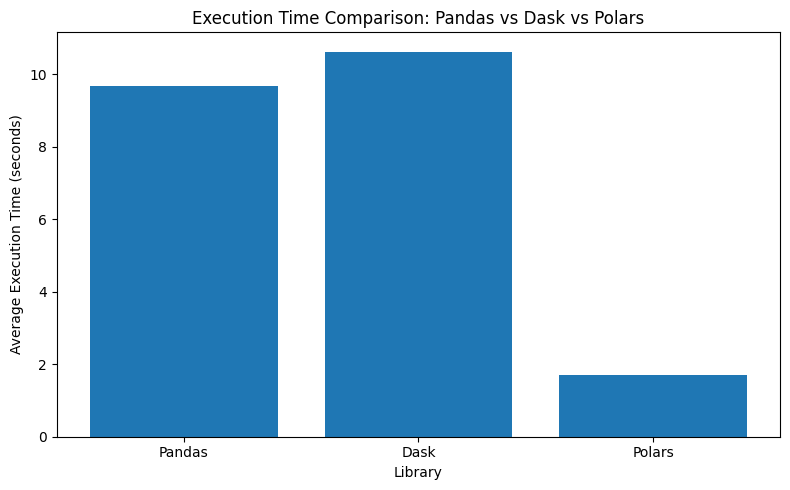

In [29]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Library"], comparison_df["Avg Execution Time (s)"])
plt.xlabel("Library")
plt.ylabel("Average Execution Time (seconds)")
plt.title("Execution Time Comparison: Pandas vs Dask vs Polars")
plt.tight_layout()
plt.show()

## 15. Chart: Peak RAM Increase Comparison

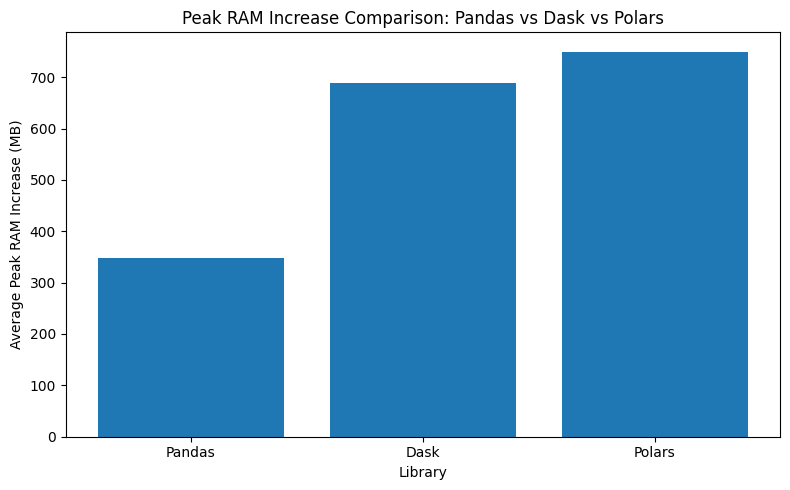

In [30]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Library"], comparison_df["Avg Peak RAM Increase (MB)"])
plt.xlabel("Library")
plt.ylabel("Average Peak RAM Increase (MB)")
plt.title("Peak RAM Increase Comparison: Pandas vs Dask vs Polars")
plt.tight_layout()
plt.show()

## 16. Critical Analysis

###### Table 16.1 Summary of Benchmark Results
<br>

| Library | Execution Time (s) | Peak RAM Increase (MB) | Key Advantage                          |
| ------- | -----------------: | ---------------------: | -------------------------------------- |
| Pandas  |              9.671 |                347.371 | Simplicity and memory efficiency       |
| Dask    |             10.618 |                687.837 | Scalability and distributed processing |
| Polars  |              1.695 |                749.777 | Fastest execution performance          |

---
The benchmark results show that Polars achieved the fastest average execution time of 1.695 seconds, significantly outperforming Pandas (9.671 seconds) and Dask (10.618 seconds). This highlights the efficiency of Polars for data processing tasks on a single machine. Although Dask supports parallel and distributed processing, its performance in this experiment was affected by the additional overhead of task scheduling and partition management, resulting in a slightly slower execution time than Pandas.

In terms of memory usage, Pandas recorded the lowest average peak RAM increase at 347.371 MB, while Dask and Polars used 687.837 MB and 749.777 MB respectively. These results show that faster execution does not always lead to lower memory consumption. Overall, each library has its own strengths: Pandas is suitable for simple data analysis, Dask is ideal for scalable and distributed workloads, and Polars provides the best execution performance for analytical tasks. Therefore, the most suitable choice depends on the required balance between speed, memory efficiency, scalability, and ease of use.


## 17. Conclusion and Scalability Reflection

This assignment highlights the importance of selecting appropriate big data processing techniques to improve performance and manage memory efficiently. The results showed that Polars achieved the fastest execution time, Pandas had the lowest peak memory usage, and Dask provided better scalability through partition-based processing.

Each library is suitable for different scenarios. Polars is ideal for fast in-memory processing, Pandas is convenient for general data analysis, and Dask is better suited for handling larger datasets that require distributed processing. As dataset sizes increase from gigabytes to terabytes, more advanced solutions such as Dask, Apache Spark, and cloud-based platforms become necessary. Using efficient storage formats such as Parquet can also improve performance and reduce storage requirements.

In conclusion, no single library is the best in all situations. The choice depends on the required balance between performance, memory efficiency, scalability, and ease of use.